In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
import sys
project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [2]:
BASE_PATH = os.getenv("BASE_PATH")
df = pd.read_parquet(f"{BASE_PATH}/data/processed/clean_weather_training_data.parquet")
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,Albury,13.4,22.900000,0.6,NaN,NaN,W,44.0,W,WNW,...,71.0,22.0,1007.700012,1007.099976,8,7,16.900000,21.799999,No,False
1,Albury,7.4,25.100000,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,44.0,25.0,1010.599976,1007.799988,8,7,17.200001,24.299999,No,False
2,Albury,17.5,32.299999,1.0,NaN,NaN,W,41.0,ENE,NW,...,82.0,33.0,1010.799988,1006.000000,7,8,17.799999,29.700001,No,False
3,Albury,14.6,29.700001,0.2,NaN,NaN,WNW,56.0,W,W,...,55.0,23.0,1009.200012,1005.400024,8,7,20.600000,28.900000,No,False
4,Albury,7.7,26.700001,0.0,NaN,NaN,W,35.0,SSE,W,...,48.0,19.0,1013.400024,1010.099976,8,7,16.299999,25.500000,No,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 99486 entries, 0 to 99515
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Location       99486 non-null  category
 1   MinTemp        99486 non-null  float32 
 2   MaxTemp        99486 non-null  float32 
 3   Rainfall       99486 non-null  float32 
 4   Evaporation    56985 non-null  float32 
 5   Sunshine       52199 non-null  float32 
 6   WindGustDir    99486 non-null  category
 7   WindGustSpeed  99486 non-null  float32 
 8   WindDir9am     99486 non-null  category
 9   WindDir3pm     99486 non-null  category
 10  WindSpeed9am   99486 non-null  float32 
 11  WindSpeed3pm   99486 non-null  float32 
 12  Humidity9am    99486 non-null  float32 
 13  Humidity3pm    99486 non-null  float32 
 14  Pressure9am    99486 non-null  float32 
 15  Pressure3pm    99486 non-null  float32 
 16  Cloud9am       99486 non-null  Int8    
 17  Cloud3pm       99486 non-null  Int8    
 18  Te

In [4]:
df.isna().sum()

Location             0
MinTemp              0
MaxTemp              0
Rainfall             0
Evaporation      42501
Sunshine         47287
WindGustDir          0
WindGustSpeed        0
WindDir9am           0
WindDir3pm           0
WindSpeed9am         0
WindSpeed3pm         0
Humidity9am          0
Humidity3pm          0
Pressure9am          0
Pressure3pm          0
Cloud9am             0
Cloud3pm             0
Temp9am              0
Temp3pm              0
RainToday            0
RainTomorrow         0
dtype: int64

### Univariate Analysis

In [5]:
from src.utils import set_labels, highlight_max_bar

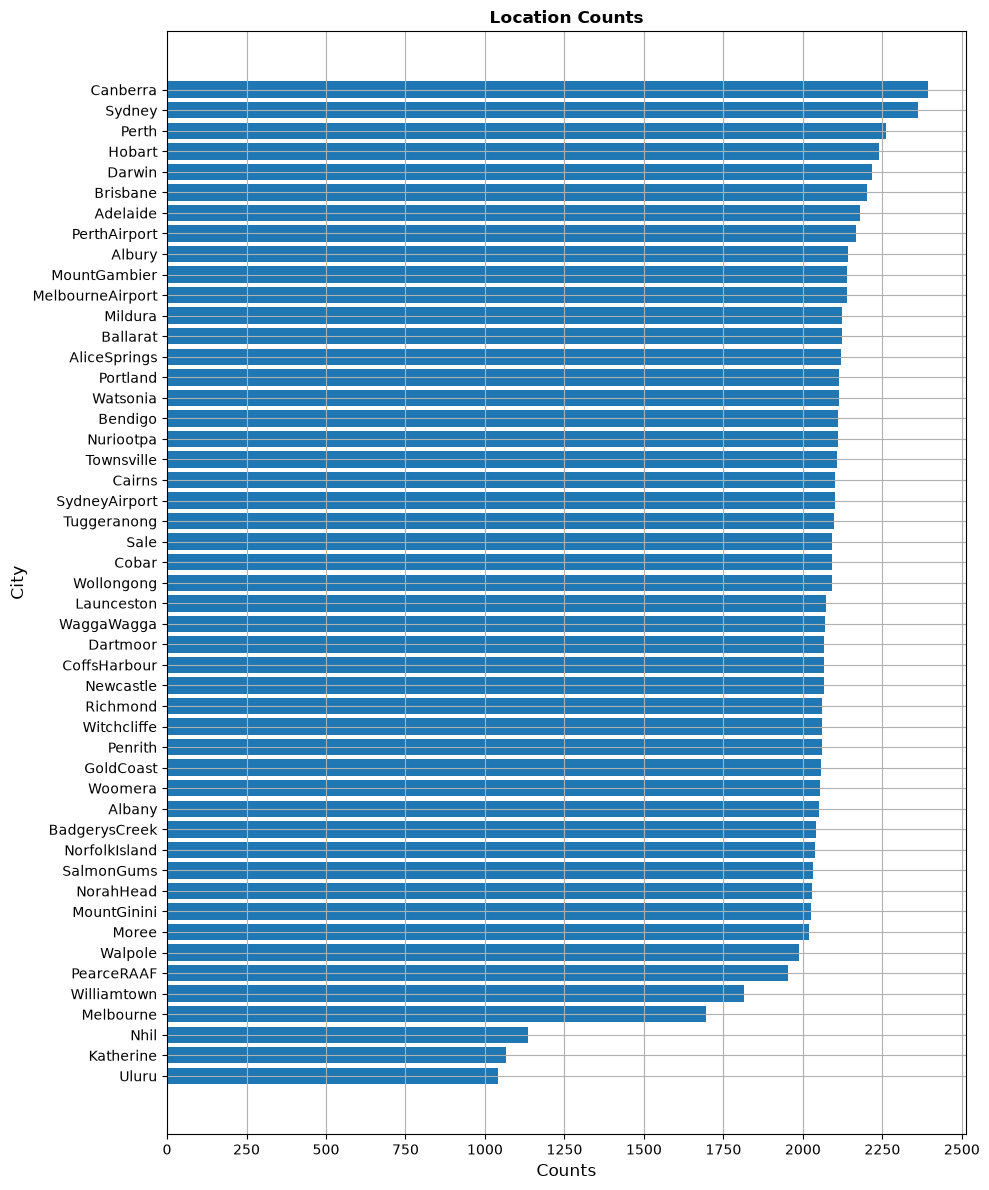

In [55]:
location_counts = df['Location'].value_counts()
fig, ax = plt.subplots(figsize=(10, 12))

ax.barh(
    location_counts.index,
    location_counts.values) # type: ignore
set_labels("Location Counts", "Counts", "City")
plt.xticks(range(0, 2750, 250))
ax.invert_yaxis()
plt.tight_layout()
plt.grid()
plt.show()

#### Observations

- **Canberra** has the highest number of records in the dataset, with **more than 2,250 observations**.
- **Sydney** ranks second, with a count slightly lower than Canberra but still **above 2,250 observations**.
- **Perth** is the third most frequent city, with **approximately 2,250 observations**.
- The majority of cities, from **Perth** to **Williamtown**, have observation counts ranging between **1,750 and 2,250**.
- Only **three cities** have observation counts in the range of **1,000 to 1,750**.

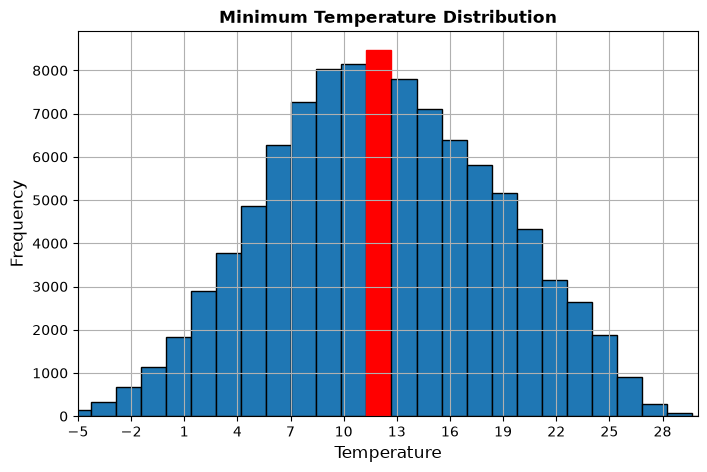

In [59]:
fig,ax = plt.subplots(figsize=(8,5))
plt.hist(df['MinTemp'], bins=30, edgecolor='black')
highlight_max_bar(ax)
plt.xticks(range(-5, 35, 3))
plt.xlim(-5, 30)
set_labels("Minimum Temperature Distribution", "Temperature", "Frequency")
plt.grid()
plt.show()

#### Observations

- The most frequently occurring **minimum temperature** is **12°C**, with **more than 8,000 observations**.
- The highest concentration of minimum temperatures falls between **7°C and 16°C**, where each temperature value has **over 7,000 observations**.
- Between **-5°C and 7°C**, the frequency changes gradually, with differences of approximately **500–600 observations** between every 2–3°C.
- After **16°C**, the frequency declines steadily, dropping to **fewer than 1,000 observations** by around **28°C**, where occurrences become rare.
- **Sub-zero temperatures (below 0°C)** are relatively uncommon, with **fewer than 1,000 observations** for each temperature value.

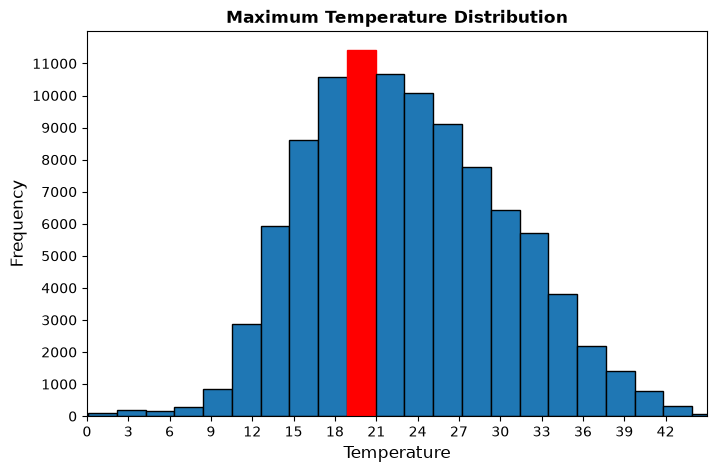

In [62]:
fig,ax = plt.subplots(figsize=(8,5))
plt.hist(df['MaxTemp'], bins=25, edgecolor='black')
plt.xlim(0, 45)
plt.xticks(range(0 ,45, 3))
plt.yticks(range(0, 12000, 1000))
highlight_max_bar(ax)
set_labels("Maximum Temperature Distribution", "Temperature", "Frequency")
plt.show()

#### Observations

- The most frequently occurring **maximum temperature** is **20°C**, with **more than 11,000 observations**.
- The highest concentration of maximum temperatures lies between **16°C and 27°C**, where each temperature value has **over 9,000 observations**.
- Maximum temperatures between **0°C and 9°C** are relatively uncommon, with **fewer than 1,000 observations** for each value. Occurrences at **0°C** are almost negligible.
- The frequency of maximum temperatures decreases sharply beyond **31°C**, with counts falling below **1,000 observations** by around **40°C**.

601


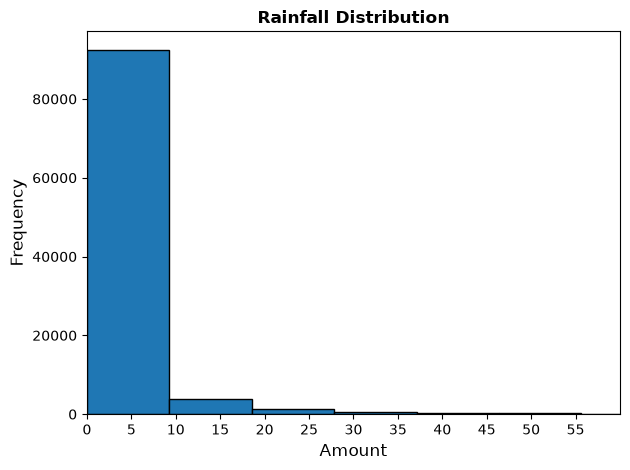

In [64]:
# Rainfall Distribution
print(df['Rainfall'].nunique())
plt.hist(df['Rainfall'], bins=40, edgecolor='black')
set_labels("Rainfall Distribution", "Amount", "Frequency")
plt.xticks(range(0, 60, 5))
plt.xlim(0, 60)
plt.tight_layout()
plt.show()

#### Observations

- The rainfall distribution is **highly right-skewed (positively skewed)**, indicating that most observations correspond to very low rainfall amounts.
- The **first bin (0–25 mm)** contains the overwhelming majority of observations, with **nearly 100,000 records**, suggesting that most days experience little or no rainfall.
- Rainfall amounts between **25 mm and 50 mm** occur relatively infrequently, accounting for only a small fraction of the dataset.
- Rainfall values **above 50 mm** are extremely rare, with almost no observations in the higher bins.
- Overall, the distribution indicates that **low or zero rainfall is common**, while **heavy rainfall events are uncommon**.

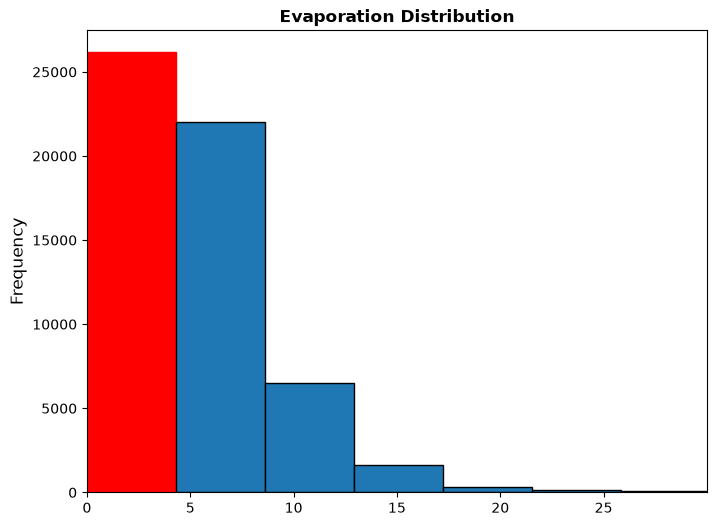

In [11]:
# Evaporation Distribution
fig, ax = plt.subplots(figsize=(8,6))
df['Evaporation'].value_counts().head(10)
plt.xticks(range(0, 30, 5))
plt.xlim(0, 30)
plt.hist(df['Evaporation'], bins=20, edgecolor='black')
highlight_max_bar(ax)
set_labels("Evaporation Distribution")
plt.show()

### Evaporation represents the amount of water that evaporates from a standard open water surface during a 24-hour period. It is typically measured in millimeters (mm).

#### Observations

- The highest concentration of evaporation values falls between **0 and 5 mm**, with **more than 25,000 observations**.
- The second most common range is **5–9 mm**, accounting for **approximately 21,000 observations**.
- A sharp decline in frequency occurs after **9 mm**, with the **9–13 mm** range containing only **around 6,000 observations**.
- Evaporation values between **13 mm and 17 mm** are relatively uncommon, each range containing **fewer than 3,000 observations**.
- Evaporation values **above 17 mm** are extremely rare, with frequencies approaching zero.

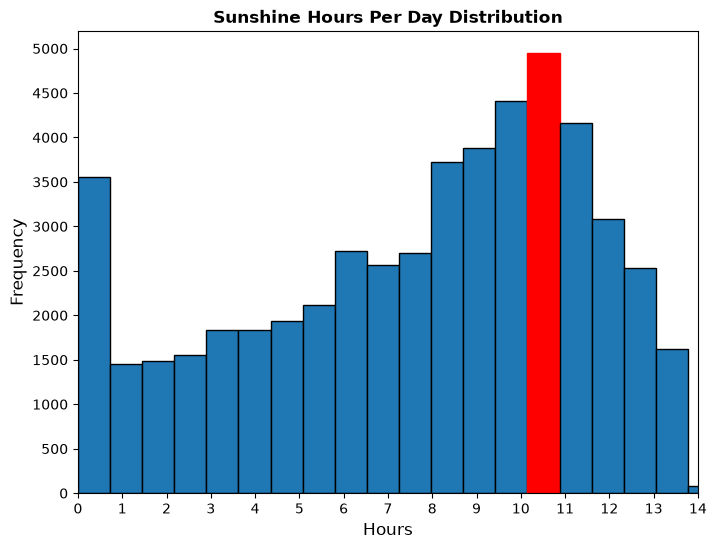

In [68]:
# Sunshine Hours Per Day
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Sunshine'], bins=20, edgecolor='black')
plt.yticks(range(0, 5500, 500))
plt.xlim(0, 14)
plt.xticks(range(0, 15, 1))
highlight_max_bar(ax)
set_labels("Sunshine Hours Per Day Distribution", "Hours", "Frequency")
plt.show()

#### Observations

- The most frequently occurring **sunshine duration** is **11 hours per day**, with **nearly 5,000 observations**.
- The highest concentration of sunshine hours falls between **8 and 11 hours**, where each value has **more than 3,500 observations**.
- **0 hours of sunshine** is also relatively common, with **approximately 3,500 observations**, indicating many completely overcast days.
- Sunshine durations between **1 and 6 hours** have moderate frequencies, ranging from **1,500 to 2,000 observations**.
- A noticeable decline in frequency begins after **12 hours** of sunshine.
- Sunshine durations of **14 hours** are extremely rare, with observation counts **approaching zero**.

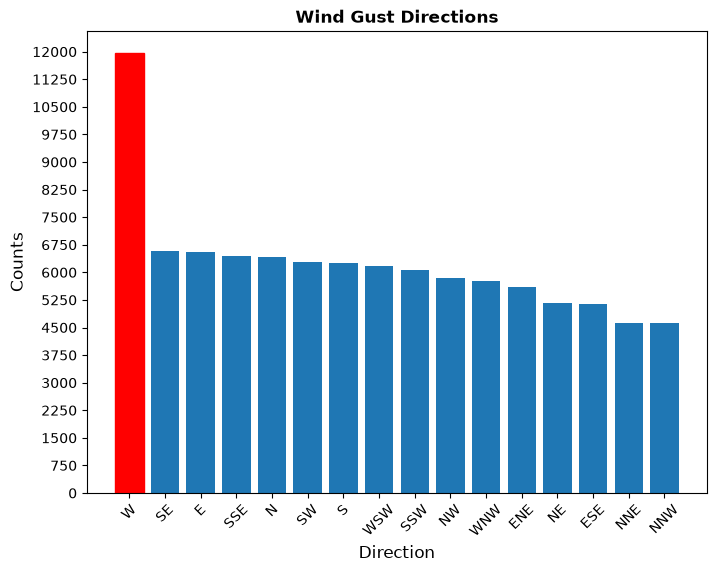

In [70]:
# WindGustDirections
fig, ax = plt.subplots(figsize=(8,6))
plt.bar(x=df['WindGustDir'].value_counts().index, 
        height=df['WindGustDir'].value_counts().values) # type: ignore
plt.yticks(range(0, 12750, 750))
set_labels("Wind Gust Directions", "Direction", "Counts")
highlight_max_bar(ax)
plt.xticks(rotation=45)
plt.show()

#### Observations

- **West (W)** is the most frequently occurring wind direction, with **approximately 12,000 observations**.
- The majority of wind directions including **SE, E, SSE, N, SW, WSW, SSW, NW, WNW, ENE, NE, and ESE** have frequencies ranging from **approximately 5,250 to 6,000 observations**, indicating a relatively balanced distribution among these directions.
- Only **NNE** and **NNW** have lower frequencies, with **around 5,000 observations** each, making them the least common wind directions in the dataset.

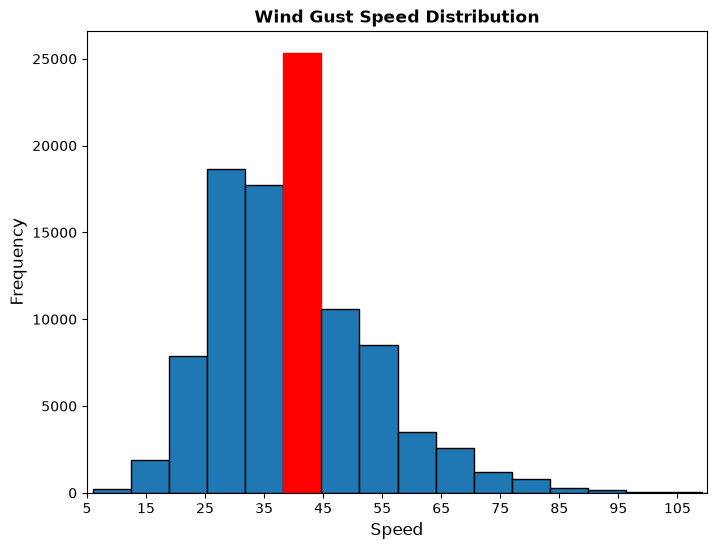

In [72]:
# WindGustSpeed
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['WindGustSpeed'], bins=20, edgecolor='black')
set_labels("Wind Gust Speed Distribution", "Speed", "Frequency")
plt.xticks(range(5, 115, 10))
plt.xlim(5, 110)
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **wind speed** values falls within the **37–45 km/h** range, with **approximately 25,000 observations**.
- The **25–36 km/h** range is the second most common, accounting for **around 18,000 observations**.
- A sharp decline in frequency occurs for wind speeds **above 45 km/h**, with counts dropping to **around 10,000 observations** initially and continuing to decrease steadily.
- Wind speeds of **80 km/h and above** are **extremely rare**, with observation counts approaching zero.

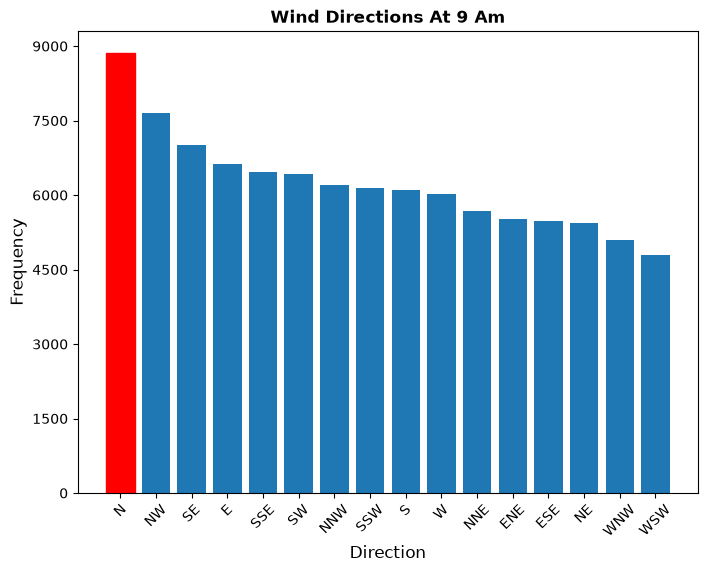

In [73]:
# WindDirections at 9am
wind_directions_9am = df['WindDir9am'].value_counts()
fig, ax = plt.subplots(figsize=(8,6))
plt.bar(x=wind_directions_9am.index,
        height=wind_directions_9am.values, # type: ignore
        )
set_labels('wind Directions at 9 am', "Direction", "Frequency")
plt.yticks(range(0, 10000, 1500))
highlight_max_bar(ax)
plt.xticks(rotation=45)
plt.show()

#### Observations

- **North (N)** is the most frequently occurring wind direction, with **approximately 9,000 observations**.
- **Northwest (NW)** ranks second, with **around 7,500 observations**.
- Most other wind directions—including **SE, E, SSE, SW, NNW, SSW, S, W, NNE, ENE, ESE, and NE**—have frequencies ranging from **approximately 6,000 to 7,000 observations**, indicating a relatively balanced distribution.
- **WNW** and **WSW** are the least frequent wind directions, each with **slightly fewer than 6,000 observations**, though both still exceed **5,800 observations**.

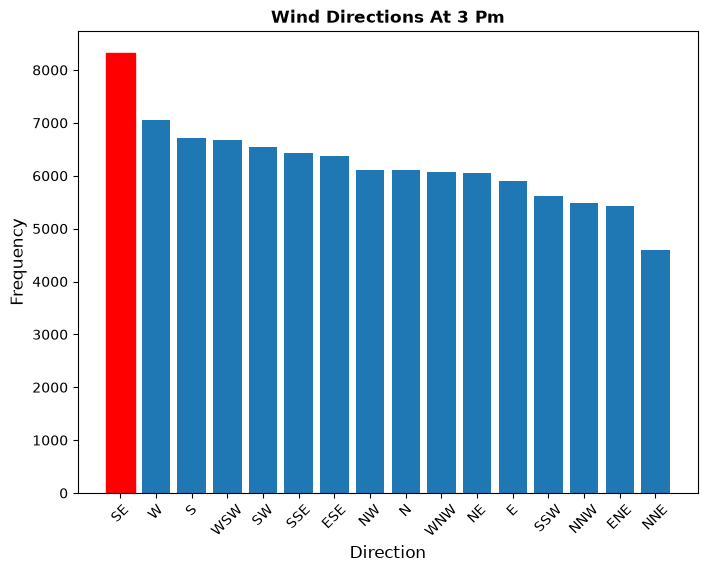

In [16]:
# WindDirections at 3pm
wind_directions_3pm = df['WindDir3pm'].value_counts()
fig, ax = plt.subplots(figsize=(8,6))
plt.bar(x=wind_directions_3pm.index,
        height=wind_directions_3pm.values, # type: ignore
        )
set_labels('wind Directions at 3 pm', "Direction", "Frequency")
highlight_max_bar(ax)
plt.xticks(rotation=45)
plt.show()

#### Observations

- **Southeast (SE)** is the most frequently occurring wind direction at **3 PM**, with **more than 8,000 observations**.
- **West (W)** ranks second, with **approximately 7,000 observations**.
- The remaining wind directions have relatively similar frequencies, ranging from **approximately 5,500 to 6,500 observations**, indicating only minor differences among them.
- **North-Northeast (NNE)** is the least frequently occurring wind direction at **3 PM**, with **around 5,000 observations**.

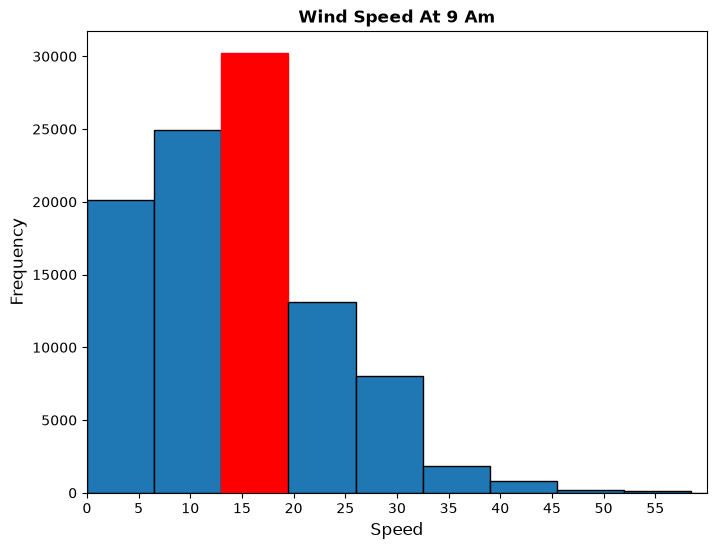

In [17]:
# WindSpeed at 9am
wind_speed_9am = df['WindSpeed9am'].value_counts()
fig, ax = plt.subplots(figsize = (8,6))
plt.hist(df['WindSpeed9am'], bins=20, edgecolor='black')
plt.xlim(0, 60)
plt.xticks(range(0, 60, 5))
set_labels("Wind Speed at 9 am", 'Speed')
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **wind speeds at 9 AM** falls within the **13–20 km/h** range, with **approximately 30,000 observations**.
- The **6–12 km/h** range is the second most common, accounting for **around 25,000 observations**.
- Wind speeds between **0 and 5 km/h** rank third, with **approximately 20,000 observations**.
- A sharp decline in frequency occurs for wind speeds **above 20 km/h**, with counts dropping from **around 15,000 observations** and decreasing steadily.
- Wind speeds of **45 km/h and above** are **extremely rare**, with observation counts approaching zero.

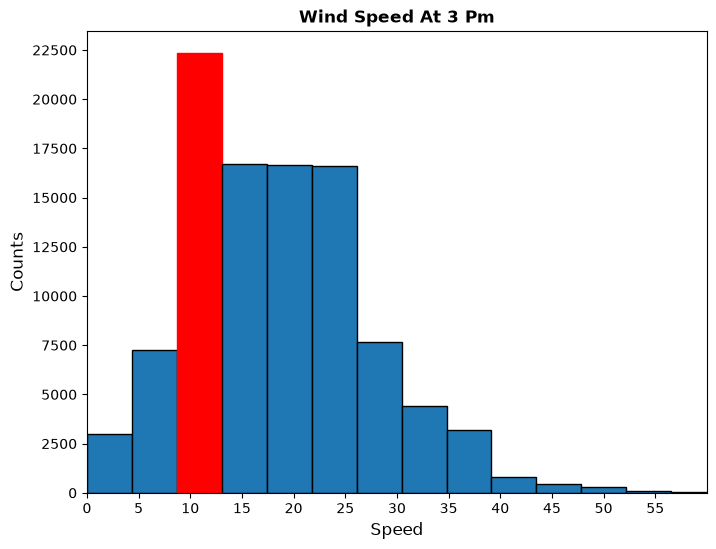

In [74]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['WindSpeed3pm'], bins=20, edgecolor='black')
plt.xlim(0, 60)
plt.xticks(range(0, 60, 5))
plt.yticks(range(0, 25000, 2500))
set_labels("Wind Speed at 3 pm", "Speed", 'Counts')
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **wind speeds at 3 PM** falls within the **9–13 km/h** range, with **approximately 22,500 observations**.
- Wind speeds between **14 and 26 km/h** occur at relatively similar frequencies, with **around 15,800 observations** in each range.
- A sharp decline in frequency is observed for wind speeds **above 26 km/h**, with counts dropping to **approximately 7,500 observations** initially and continuing to decrease until they become nearly zero by **52 km/h**.
- Wind speeds in the **0–5 km/h** range account for **approximately 2,500 observations**, while those in the **5–9 km/h** range account for **around 7,500 observations**.

In [20]:
# Humidity reference:
# 20%  -> Very dry air
# 50%  -> Moderate and comfortable humidity
# 80%  -> Humid air
# 100% -> Air is fully saturated with water vapor; fog or rain may form

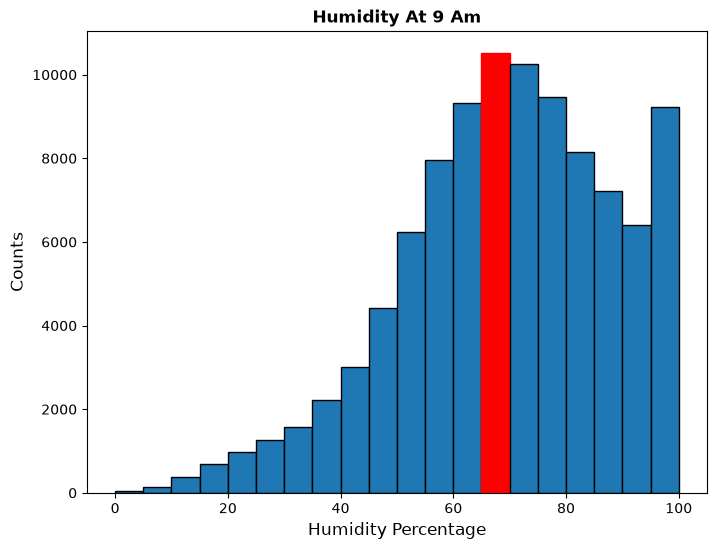

In [21]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(x=df["Humidity9am"], bins=20, edgecolor='black')
set_labels("Humidity at 9 am", "Humidity Percentage", "Counts")
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **humidity at 9 AM** falls between **65% and 75%**, with the peak occurring at **approximately 68–70%**, reaching **more than 10,000 observations**.
- Most humidity values lie within the **60%–85%** range, indicating that mornings are generally characterized by **moderate to high humidity**.
- Humidity levels **below 40%** are relatively uncommon, with frequencies decreasing steadily as humidity decreases.
- Very low humidity values (**below 20%**) are rare, accounting for only a small number of observations.
- The distribution is **left-skewed (negatively skewed)**, with a long tail toward lower humidity values and a high concentration of observations at higher humidity levels.
- A noticeable number of observations also occur at **100% humidity**, suggesting that fully saturated atmospheric conditions are relatively common in the dataset.

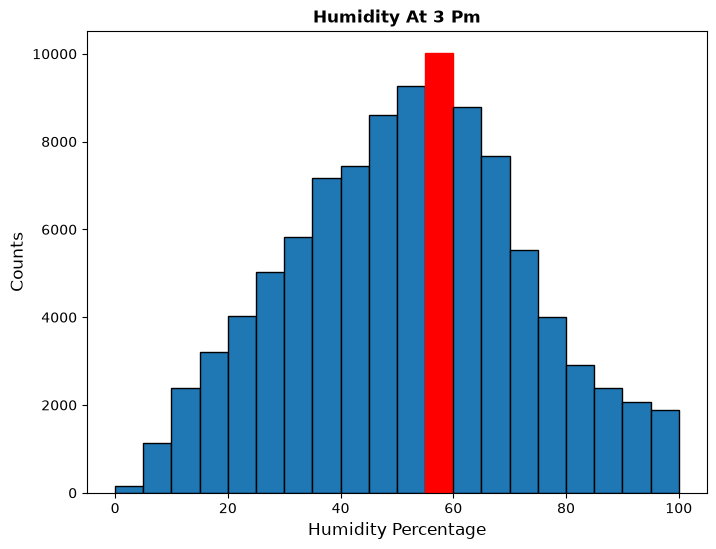

In [22]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(x=df["Humidity3pm"], bins=20, edgecolor='black')
set_labels("Humidity at 3 pm", "Humidity Percentage", "Counts")
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **humidity at 3 PM** falls between **50% and 65%**, with the peak occurring at **approximately 58–60%**, reaching **around 10,000 observations**.
- Most afternoon humidity values are concentrated within the **40%–70%** range, indicating that moderate humidity levels are the most common during this time of day.
- Humidity values **below 20%** are relatively uncommon, with frequencies increasing gradually as humidity rises toward the peak.
- After **60% humidity**, the frequency declines steadily, although high humidity values (up to **100%**) are still observed.
- The distribution is **slightly right-skewed (positively skewed)**, with a longer tail extending toward higher humidity values.
- Compared with **9 AM**, the distribution is shifted toward **lower humidity levels**, reflecting the typical decrease in humidity during the afternoon as temperatures rise.

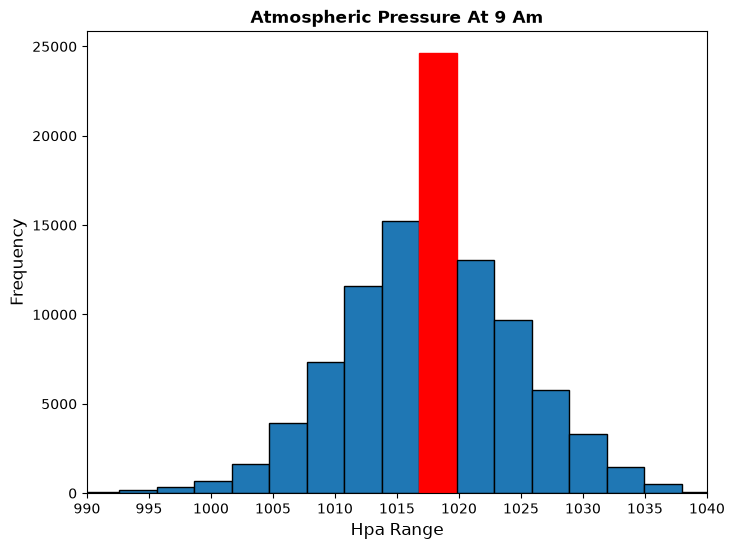

In [32]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Pressure9am'], bins=20, edgecolor='black')
plt.xlim(990, 1040)
plt.xticks(range(990, 1045, 5))
set_labels("Atmospheric Pressure at 9 am", "HPA Range", "Frequency")
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **atmospheric pressure at 9 AM** falls between **1015 and 1020 hPa**, with the peak occurring at **approximately 1018 hPa**, reaching **nearly 25,000 observations**.
- Most pressure values are concentrated within the **1010–1025 hPa** range, indicating that atmospheric pressure is generally close to the average sea-level pressure.
- Pressure values **below 1005 hPa** are relatively uncommon, with frequencies decreasing steadily as pressure decreases.
- Similarly, pressure values **above 1030 hPa** are rare, with observation counts dropping sharply.
- The distribution is **approximately bell-shaped (close to a normal distribution)**, centered around **1018 hPa**, suggesting that extreme pressure values are much less frequent than moderate values.

### Atmospheric Pressure (hPa)

A range of **1000–1040 hPa** is very common in weather.

| Pressure (hPa) | Meaning | Typical Weather |
|----------------|---------|-----------------|
| **< 1000** | Low pressure | Cloudy, windy, rain or storms more likely |
| **1000–1013** | Slightly low | Some clouds, possible rain |
| **1013** | Average sea-level pressure | Normal weather |
| **1014–1025** | High pressure | Clear skies, calm, stable weather |
| **1026–1040** | Very high pressure | Dry, sunny, little wind |
| **> 1040** | Extremely high pressure | Rare; very stable cold or dry conditions |

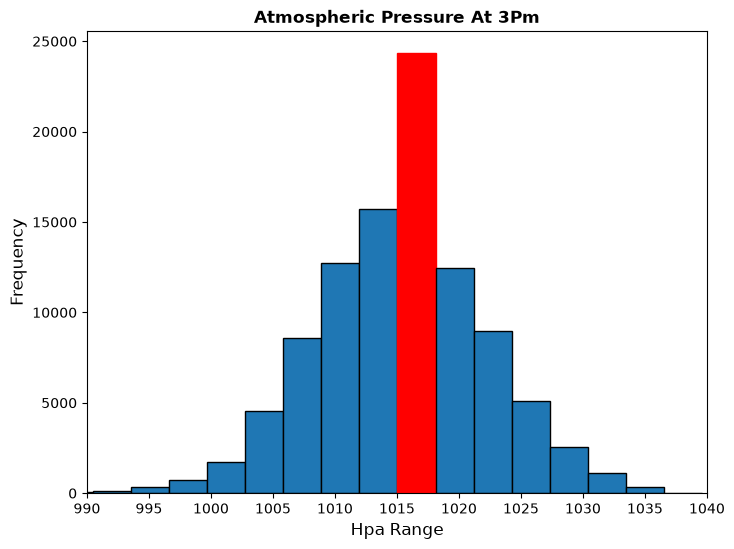

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Pressure3pm'], bins=20, edgecolor='black')
plt.xlim(990, 1040)
plt.xticks(range(990, 1045, 5))
set_labels("Atmospheric Pressure at 3pm", "HPA Range", "Frequency")
highlight_max_bar(ax)
plt.show()

#### Observations

- The highest concentration of **atmospheric pressure at 3 PM** falls between **1014 and 1019 hPa**, with the peak occurring at **approximately 1017 hPa**, reaching **nearly 24,000 observations**.
- Most pressure values are concentrated within the **1010–1024 hPa** range, indicating that afternoon atmospheric pressure is generally close to the average sea-level pressure.
- Pressure values **below 1005 hPa** are relatively uncommon, with frequencies decreasing steadily as pressure decreases.
- Likewise, pressure values **above 1030 hPa** are rare, with observation counts dropping sharply.
- The distribution is **approximately bell-shaped (close to a normal distribution)** and centered around **1017 hPa**, indicating that moderate pressure values are far more common than extreme values.
- Compared with **9 AM**, the pressure distribution is **slightly shifted toward lower values**, although the overall shape remains very similar.

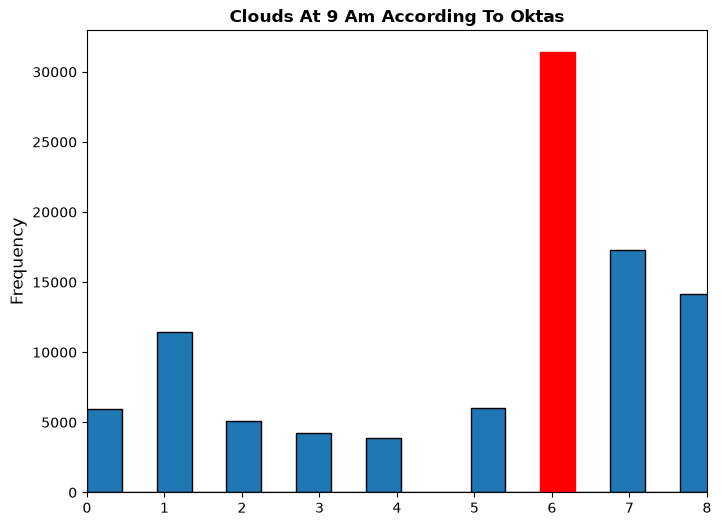

In [43]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Cloud9am'], bins=20, edgecolor='black')
highlight_max_bar(ax)
set_labels("Clouds at 9 am According to Oktas")
plt.xlim(0, 8)
plt.show()

#### Observations

- The most frequently occurring **cloud cover at 9 AM** is **6 oktas**, with **more than 31,000 observations**, making it the dominant cloud cover level in the dataset.
- **7 oktas** and **8 oktas** are the second and third most common cloud cover values, with **approximately 17,000** and **14,000 observations**, respectively.
- Lower cloud cover levels (**0–5 oktas**) occur much less frequently, each accounting for **fewer than 12,000 observations**.
- Among the lower cloud cover categories, **1 okta** is the most common, with **around 11,000 observations**, while **4 oktas** is the least common, with **approximately 4,000 observations**.
- Overall, the distribution indicates that **moderate to heavy cloud cover (6–8 oktas)** is considerably more common than **clear or partly cloudy conditions (0–5 oktas)**.

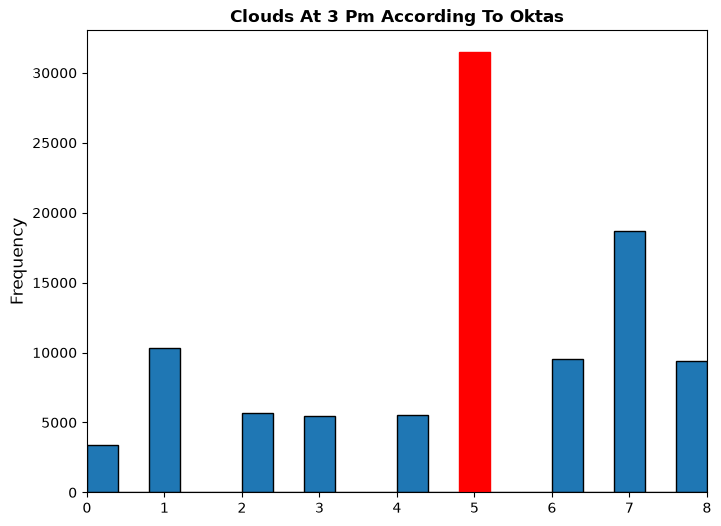

In [44]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Cloud3pm'], bins=20, edgecolor='black')
highlight_max_bar(ax)
set_labels("Clouds at 3 pm According to Oktas")
plt.xlim(0, 8)
plt.show()

#### Observations

- The most frequently occurring **cloud cover at 3 PM** is **5 oktas**, with **more than 31,000 observations**, making it the dominant cloud cover level in the dataset.
- **7 oktas** is the second most common cloud cover category, with **approximately 19,000 observations**.
- **1 okta**, **6 oktas**, and **8 oktas** occur at moderate frequencies, with counts ranging from **approximately 9,000 to 10,500 observations**.
- Cloud cover levels of **2, 3, and 4 oktas** have similar frequencies, each accounting for **around 5,500 observations**.
- **0 oktas** (clear skies) is the least common cloud cover category, with **approximately 3,500 observations**.
- Overall, the distribution indicates that **moderate to high cloud cover (5–8 oktas)** is substantially more common than **clear or lightly cloudy conditions (0–4 oktas)** during the afternoon.

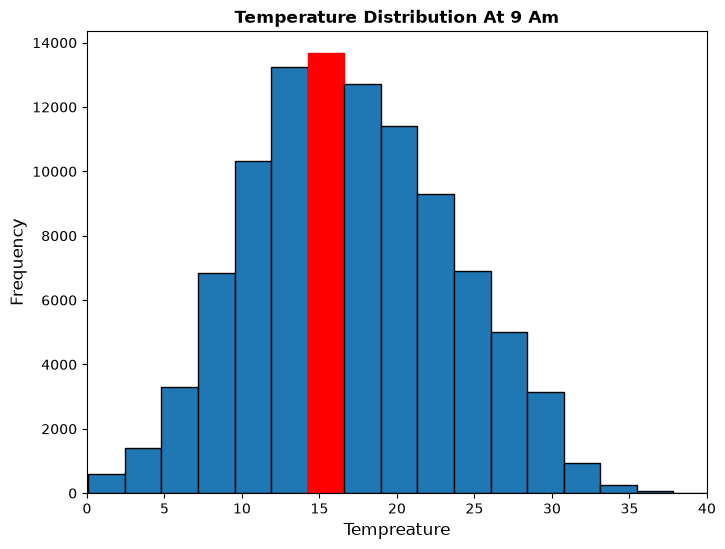

In [47]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Temp9am'], bins=20, edgecolor='black')
plt.xlim(0 , 40)
plt.xticks(range(0, 45, 5))
highlight_max_bar(ax)
set_labels("Temperature Distribution at 9 am", "Tempreature", "Frequency")
plt.show()

#### Observations

- The highest concentration of **temperature at 9 AM** falls between **12°C and 18°C**, with the peak occurring at **approximately 15°C**, reaching **nearly 14,000 observations**.
- Most 9 AM temperatures are concentrated within the **10°C–22°C** range, indicating that mild morning temperatures are the most common.
- Temperatures **below 5°C** are relatively uncommon, with frequencies decreasing steadily toward **0°C**.
- Likewise, temperatures **above 30°C** are rare, with observation counts approaching zero beyond **35°C**.
- The distribution is **approximately bell-shaped (close to a normal distribution)**, centered around **15°C**, suggesting that moderate temperatures occur much more frequently than extreme cold or hot temperatures.

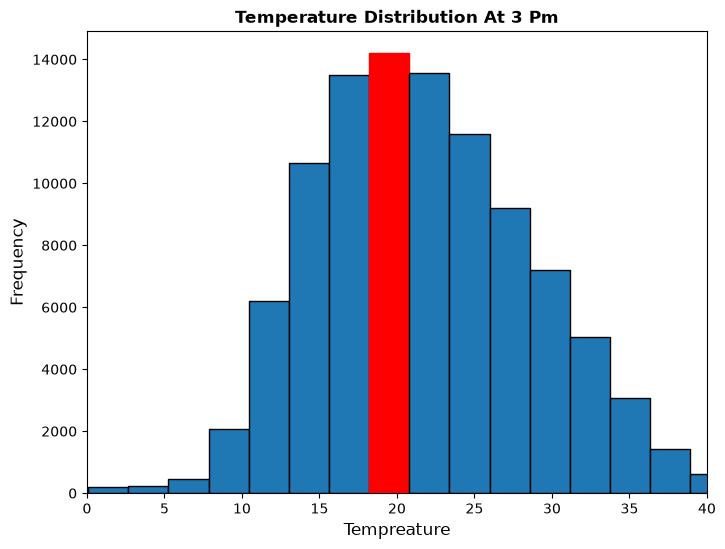

In [49]:
fig, ax = plt.subplots(figsize=(8,6))
plt.hist(df['Temp3pm'], bins=20, edgecolor='black')
plt.xlim(0 , 40)
plt.xticks(range(0, 45, 5))
highlight_max_bar(ax)
set_labels("Temperature Distribution at 3 pm", "Tempreature", "Frequency")
plt.show()

#### Observations

- The highest concentration of **temperature at 3 PM** falls between **18°C and 24°C**, with the peak occurring at **approximately 20°C**, reaching **more than 14,000 observations**.
- Most 3 PM temperatures are concentrated within the **15°C–28°C** range, indicating that warm afternoon temperatures are the most common.
- Temperatures **below 10°C** are relatively uncommon, with frequencies decreasing steadily toward **0°C**.
- Likewise, temperatures **above 35°C** are rare, with observation counts approaching zero near **40°C**.
- The distribution is **approximately bell-shaped (close to a normal distribution)**, centered around **20°C**, suggesting that moderate afternoon temperatures occur much more frequently than extreme cold or hot temperatures.
- Compared with **9 AM**, the temperature distribution is **shifted toward higher values**, reflecting the typical warming of the atmosphere during the afternoon.

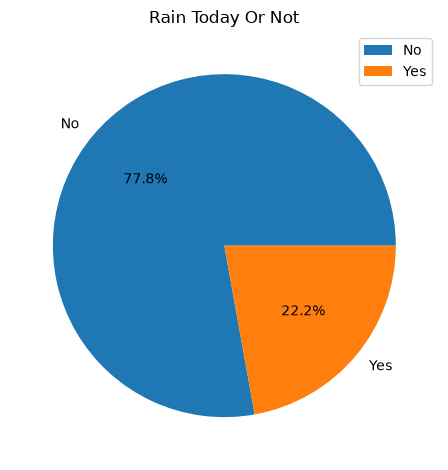

In [52]:
rain_today_counts = df['RainToday'].value_counts()
plt.pie(
    rain_today_counts.values, # type: ignore
    labels=rain_today_counts.index, # type: ignore
    autopct="%1.1f%%"   
    )

plt.title("Rain Today Or Not")
plt.tight_layout()
plt.legend()
plt.show()

#### Observations

- The dataset is **imbalanced**, with the majority of observations indicating **no rainfall**.
- **77.8%** of the records are labeled **"No"**, meaning that rain did not occur on most days.
- Only **22.2%** of the records are labeled **"Yes"**, indicating that rainy days are considerably less frequent.
- The proportion of **non-rainy days** is more than **three times** that of **rainy days**.
- This class imbalance should be considered when building predictive models, as it may bias the model toward predicting the majority class unless appropriate techniques are applied.

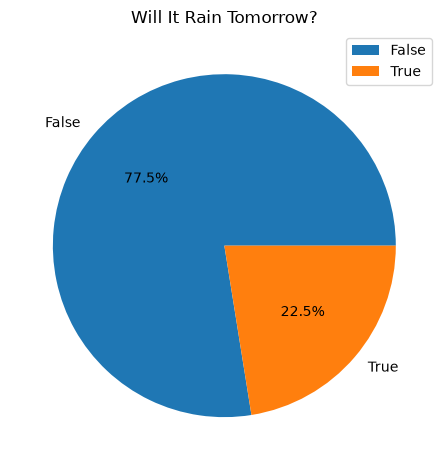

In [53]:
rain_tomorrow_counts = df['RainTomorrow'].value_counts()
plt.pie(
    rain_tomorrow_counts.values, # type: ignore
    labels=rain_tomorrow_counts.index, # type: ignore
    autopct="%1.1f%%"   
    )

plt.title("Will It Rain Tomorrow?")
plt.tight_layout()
plt.legend()
plt.show()